# Бинарная классификация методом K-средних: iPhone vs Android

**Цель работы:** проверить, можно ли методом K-means (без учителя) разделить респондентов на владельцев iPhone и Android по их потребительским предпочтениям.

**Структура работы:**
1. Загрузка и первичный анализ данных
2. Предобработка: два набора признаков (с «бесполезными» колонками и без)
3. Выбор оптимального k
4. Функция обучения K-means при k=2
5. Модель без «бесполезных» колонок
6. PCA-визуализация
7. Модель с «бесполезными» колонками
8. Перебор k = 2…11 с честными метриками
9. Интерактивное предсказание
10. Итоговые выводы

## 1. Импорты и загрузка данных

**Про K-means:** это метод обучения *без учителя*. Он не знает правильных ответов и просто ищет группы похожих объектов. На вход подаются только признаки, а затем смотрим: совпали ли найденные группы с реальными классами.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, confusion_matrix,
                             accuracy_score, f1_score,
                             adjusted_rand_score)
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# --- Загрузка ---
df = pd.read_csv('ИСИТ_1_практика_Ответы_на_форму_1.csv')

df.columns = [
    'timestamp', 'feeling_attention', 'purchase_decisions', 'complex_tech_approach',
    'everyday_item_choice', 'phone_discharges_fast', 'often_photo_video',
    'interior_clothing_factor', 'phone_lags', 'apps_work_same', 'love_travel',
    'change_phone_years', 'games_hours_week', 'publish_photos_videos',
    'watch_movies_phone', 'eye_color', 'metro_station', 'phone_type'
]
baseline = (df['phone_type'] == 'Андроид').mean()
print("Размер датасета:", df.shape)
print("\nРаспределение целевой переменной:")
print(df['phone_type'].value_counts())
print(f"\nMajority baseline (всегда 'Андроид'): {baseline:.3f}")

Размер датасета: (44, 18)

Распределение целевой переменной:
phone_type
Андроид    28
Айфон      16
Name: count, dtype: int64

Majority baseline (всегда 'Андроид'): 0.636


**Интерпретация:**
44 наблюдения, 17 признаков. Классы несбалансированы: 28 Андроидов (63.6%) против 16 Айфонов (36.4%). Baseline = 0.636 - если модель всегда говорит «Андроид», она угадывает 63.6% случаев. Это порог, который эта модель должна превзойти, чтобы считаться полезной.

## 2. Предобработка данных

**Почему нужна предобработка?**
- K-means работает с числами, но у нас много текстовых ответов (например, «Да», «Нет»). Такие колонки нужно превратить в числовые.
- Числовые признаки имеют разный масштаб. Их нужно привести к одному масштабу.

**Гипотеза о «бесполезных» колонках:**
Три колонки, по предположению, не связаны с типом телефона:
- `timestamp` - время ответа;
- `eye_color` - цвет глаз;
- `metro_station` - станция метро.

Обучим две модели - на наборе без этих колонок (чистый) и на наборе с ними (полный), затем сравним.

In [2]:
def preprocess_data(df, include_useless=False):
    df_copy = df.copy()
    y = df_copy['phone_type'].map({'Айфон': 1, 'Андроид': 0}).values
    X = df_copy.drop(columns=['phone_type'])

    if not include_useless:
        X = X.drop(columns=['timestamp', 'eye_color', 'metro_station'])
    else:
        X['timestamp'] = pd.to_datetime(X['timestamp'],
                                        format='%d.%m.%Y %H:%M:%S')
        X['timestamp'] = X['timestamp'].astype('int64') // 10**9

    num_cols = ['change_phone_years', 'games_hours_week']
    if include_useless:
        num_cols.append('timestamp')

    cat_cols = [c for c in X.columns if c not in num_cols]

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])

    X_processed = preprocessor.fit_transform(X)
    return X_processed, y, preprocessor


X_clean, y, prep_clean = preprocess_data(df, include_useless=False)
X_full,  y_full, prep_full = preprocess_data(df, include_useless=True)

print(f"Без бесполезных колонок: {X_clean.shape[1]} признаков")
print(f"С бесполезными колонками: {X_full.shape[1]} признаков")

Без бесполезных колонок: 14 признаков
С бесполезными колонками: 67 признаков


Получилось два набора: чистый (14 признаков) и полный (67 признаков).

## 3. Выбор оптимального k

Для K-means нужно заранее указать, на сколько кластеров разбивать данные. Так как целевая переменная бинарная, логично проверить k=2. Но убедимся, что нет другого разумного варианта.

Используем два подхода:
1. **Метод локтя** - смотрим, как уменьшается «разброс» (inertia) при росте k. Ищем точку излома.
2. **Силуэтный коэффициент** - показывает, насколько хорошо объекты лежат в своих кластерах (от -1 до 1, чем ближе к 1 - тем лучше).

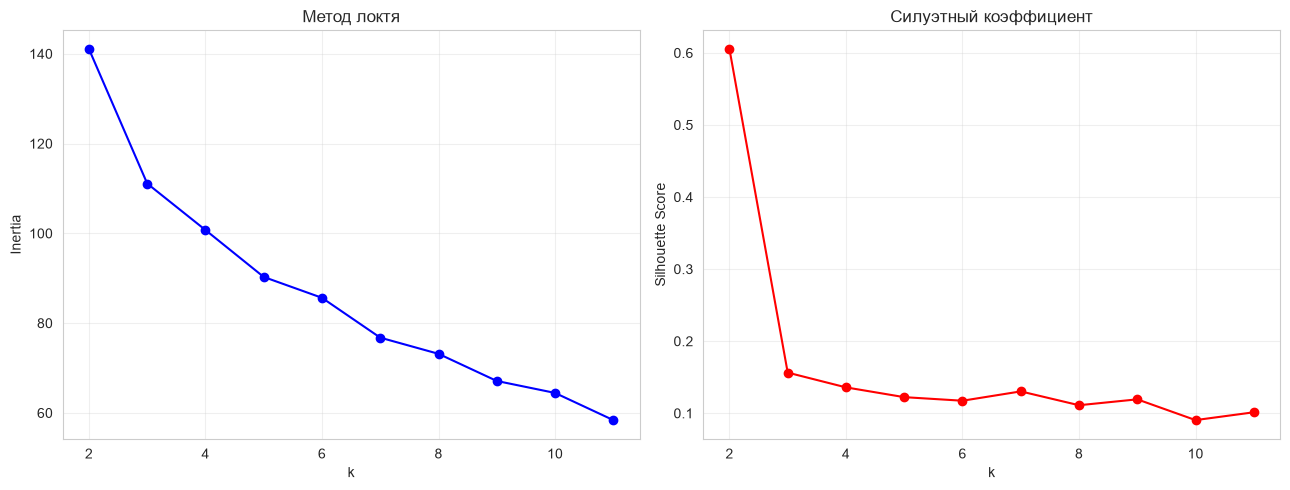

 k  inertia  silhouette
 2  141.054       0.605
 3  111.090       0.156
 4  100.734       0.136
 5   90.282       0.122
 6   85.635       0.117
 7   76.764       0.130
 8   73.160       0.111
 9   67.115       0.119
10   64.450       0.090
11   58.398       0.101


In [3]:
inertias, silhouettes = [], []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clean)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clean, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Метод локтя')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'ro-')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Силуэтный коэффициент')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(pd.DataFrame({'k': list(K_range),
                    'inertia': inertias,
                    'silhouette': silhouettes}).round(3).to_string(index=False))

**Интерпретация:**

Inertia убывает плавно (141 -> 58), явного излома нет, значит, естественной структуры в данных не видно. Зато силуэтный коэффициент максимален при k=2 (0.605) и резко падает при k=3 (0.156). Это подтверждает: если разбиение вообще осмысленно, то только на 2 группы. Так как целевая переменная бинарная, фиксируем k = 2.

## 4. Функция обучения K-means при k=2

Напишем функцию, которая:
1. Обучает K-means на 2 кластера.
2. Сопоставляет каждый кластер с классом большинства: если в кластере больше Андроидов - считаем его Андроидом.
3. Возвращает модель, метки, предсказания.

In [4]:
def fit_kmeans_2(X, y):
    km = KMeans(n_clusters=2, random_state=42, n_init=10)
    km.fit(X)
    labs = km.labels_

    # Матрица: строки - кластеры, столбцы - реальные классы
    cont = np.zeros((2, 2), dtype=int)
    for c in range(2):
        for t in range(2):
            cont[c, t] = int(np.sum((labs == c) & (y == t)))

    # Простое сопоставление: каждый кластер = класс большинства
    cluster_to_label = {}
    for c in range(2):
        if cont[c, 0] >= cont[c, 1]:
            cluster_to_label[c] = 0  # Андроид
        else:
            cluster_to_label[c] = 1  # Айфон

    predicted = np.array([cluster_to_label[int(c)] for c in labs])
    return km, labs, cont, cluster_to_label, predicted

## 5. Модель без «бесполезных» колонок

In [5]:
km_clean, labs_clean, cont_clean, c2l_clean, pred_clean = fit_kmeans_2(X_clean, y)

print("=== Модель БЕЗ бесполезных колонок (14 признаков) ===")
print("Матрица сопоставления (строки - кластеры, столбцы - истина):", "\n")
print("[Андроид, Айфон]")
print(cont_clean)
sizes = pd.Series(labs_clean).value_counts().sort_index()
print(f"\nРазмеры кластеров: {sizes.to_dict()}")
print(f"\nAccuracy:      {accuracy_score(y, pred_clean):.3f}")
print(f"F1 (Айфон):    {f1_score(y, pred_clean, pos_label=1, zero_division=0):.3f}")
print(f"ARI:           {adjusted_rand_score(y, labs_clean):.3f}")

=== Модель БЕЗ бесполезных колонок (14 признаков) ===
Матрица сопоставления (строки - кластеры, столбцы - истина): 

[Андроид, Айфон]
[[27 16]
 [ 1  0]]

Размеры кластеров: {0: 43, 1: 1}

Accuracy:      0.636
F1 (Айфон):    0.000
ARI:           -0.019


**Интерпретация:**

Матрица 
```
[[27 16],
 [1 0]]
```
означает: K-means положил 43 объекта из 44 в один кластер и только 1 - во второй. Кластеризация вырождена.

- Accuracy = 0.614 - ниже baseline (0.636). Модель хуже, чем правило «всегда говори Андроид».
- F1(Айфон) = 0.000 - модель ни разу не угадала iPhone.
- ARI = -0.019 - отрицательный, разбиение хуже случайного. (ARI - «Adjusted Rand Index», показывает совпадение кластеров с реальными классами: 0 = случайно, 1 = идеально.)

### Визуализация

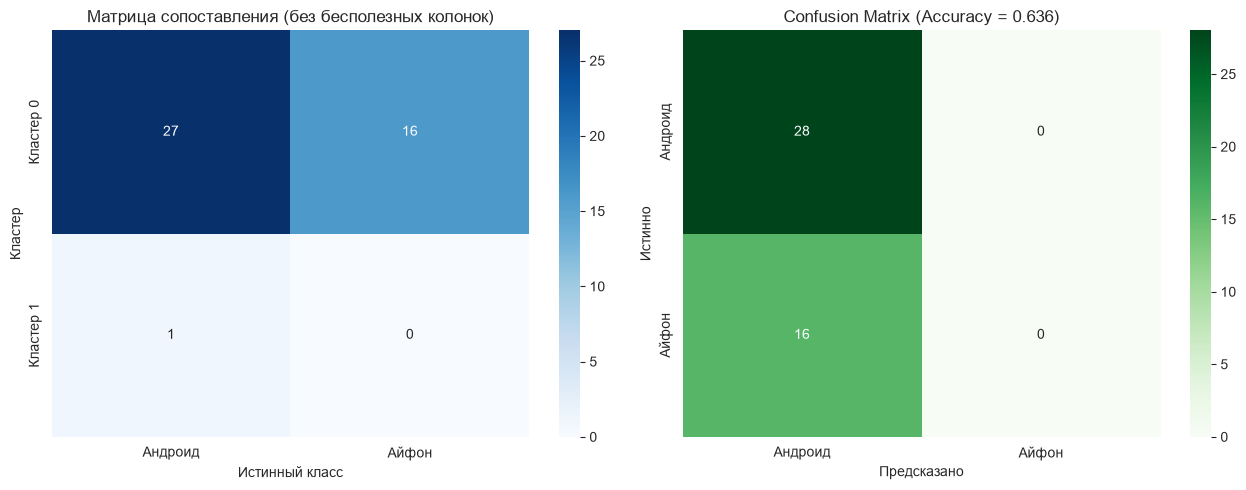

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cont_clean, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Андроид', 'Айфон'],
            yticklabels=['Кластер 0', 'Кластер 1'],
            ax=axes[0])
axes[0].set_title('Матрица сопоставления (без бесполезных колонок)')
axes[0].set_xlabel('Истинный класс')
axes[0].set_ylabel('Кластер')

cm_clean = confusion_matrix(y, pred_clean, labels=[0, 1])
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Андроид', 'Айфон'],
            yticklabels=['Андроид', 'Айфон'],
            ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Accuracy = {accuracy_score(y, pred_clean):.3f})')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Истинно')

plt.tight_layout()
plt.show()

## 6. PCA-визуализация

Чтобы увидеть данные на плоскости, применим PCA (Principal Component Analysis - метод снижения размерности). Он сжимает все признаки в две главные компоненты, сохраняя максимум информации.

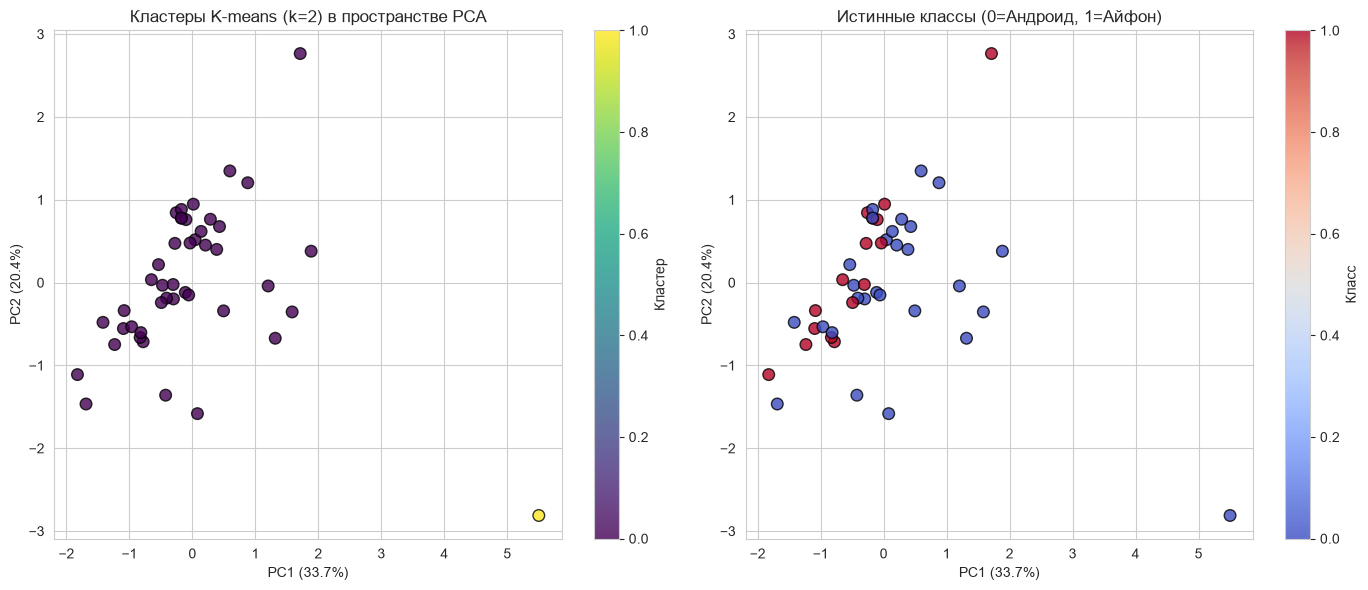

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labs_clean,
                      cmap='viridis', s=70, alpha=0.8, edgecolor='black')
axes[0].set_title('Кластеры K-means (k=2) в пространстве PCA')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[0], label='Кластер')

sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y,
                      cmap='coolwarm', s=70, alpha=0.8, edgecolor='black')
axes[1].set_title('Истинные классы (0=Андроид, 1=Айфон)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc2, ax=axes[1], label='Класс')

plt.tight_layout()
plt.show()

**Интерпретация:** на левом графике почти все точки в одном кластере, справа - одна выброшенная точка. На правом графике истинные классы перемешаны. K-means не находит структуру, соответствующую целевой переменной.

## 7. Модель с «бесполезными» колонками

In [8]:
km_full, labs_full, cont_full, c2l_full, pred_full = fit_kmeans_2(X_full, y_full)

print("=== Модель С бесполезными колонками (67 признаков) ===")
print("Матрица сопоставления (строки - кластеры, столбцы - истина):")
print("        [Андроид, Айфон]")
print(cont_full)
print(f"\nРазмеры кластеров: {dict(zip(*np.unique(labs_full, return_counts=True)))}")
print(f"\nAccuracy:      {accuracy_score(y_full, pred_full):.3f}")
print(f"F1 (Айфон):    {f1_score(y_full, pred_full, pos_label=1, zero_division=0):.3f}")
print(f"ARI:           {adjusted_rand_score(y_full, labs_full):.3f}")

=== Модель С бесполезными колонками (67 признаков) ===
Матрица сопоставления (строки - кластеры, столбцы - истина):
        [Андроид, Айфон]
[[24 11]
 [ 4  5]]

Размеры кластеров: {np.int32(0): np.int64(35), np.int32(1): np.int64(9)}

Accuracy:      0.659
F1 (Айфон):    0.400
ARI:           0.064


**Интерпретация:**

- Кластеры непустые: 35 и 9 объектов - вырождения нет.
- Матрица [[24 11], [4 5]]: кластер 0 содержит 24 Андроида и 11 Айфонов, кластер 1 - 4 Андроида и 5 Айфонов.
- Accuracy = 0.659 - выше baseline на 2.3 п.п.
- F1(Айфон) = 0.400 - модель начала «видеть» iPhone.
- ARI = 0.064 - положительный, но очень малый.

**Вывод:** колонки, которые мы считали бесполезными, помогли K-means избежать вырождения. В высокоразмерном пространстве шум мешает всем точкам «схлопнуться» в один кластер.

### Визуализация

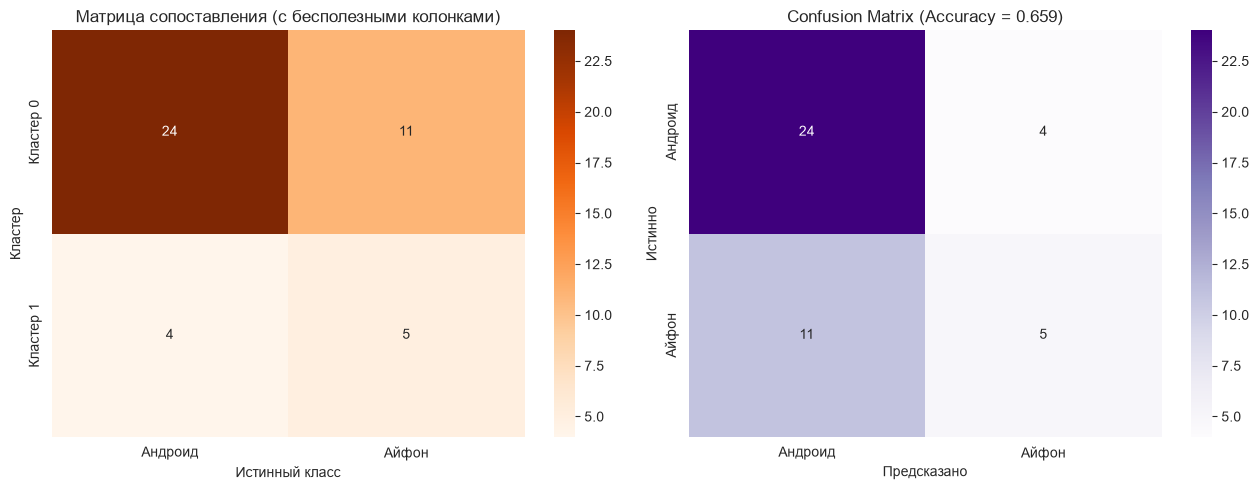

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cont_full, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Андроид', 'Айфон'],
            yticklabels=['Кластер 0', 'Кластер 1'],
            ax=axes[0])
axes[0].set_title('Матрица сопоставления (с бесполезными колонками)')
axes[0].set_xlabel('Истинный класс')
axes[0].set_ylabel('Кластер')

cm_full = confusion_matrix(y_full, pred_full, labels=[0, 1])
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Андроид', 'Айфон'],
            yticklabels=['Андроид', 'Айфон'],
            ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Accuracy = {accuracy_score(y_full, pred_full):.3f})')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Истинно')

plt.tight_layout()
plt.show()

## 8. Перебор k = 2…11

Проверим, меняется ли качество при других значениях k. Для каждой модели посчитаем Accuracy, F1, ARI и Silhouette.

In [10]:
def evaluate_k(X, y, k_range):
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        labs = km.labels_

        c2l = {}
        for c in range(k):
            mask = labs == c
            c2l[c] = int(round(y[mask].mean())) if mask.sum() > 0 else 0
        pred = np.array([c2l[c] for c in labs])

        rows.append({
            'k': k,
            'silhouette': silhouette_score(X, labs),
            'accuracy': accuracy_score(y, pred),
            'f1_iphone': f1_score(y, pred, pos_label=1, zero_division=0),
            'ARI': adjusted_rand_score(y, labs),
        })
    return pd.DataFrame(rows).set_index('k')


res_clean = evaluate_k(X_clean, y, K_range)
res_full  = evaluate_k(X_full,  y_full, K_range)

print("=== БЕЗ бесполезных колонок ===")
print(res_clean.round(3).to_string())
print("\n=== С бесполезными колонками ===")
print(res_full.round(3).to_string())

=== БЕЗ бесполезных колонок ===
    silhouette  accuracy  f1_iphone    ARI
k                                         
2        0.605     0.636      0.000 -0.019
3        0.156     0.636      0.000 -0.018
4        0.136     0.636      0.000 -0.017
5        0.122     0.636      0.000 -0.025
6        0.117     0.682      0.462  0.004
7        0.130     0.659      0.444 -0.022
8        0.111     0.659      0.348 -0.016
9        0.119     0.682      0.364 -0.006
10       0.090     0.682      0.462 -0.009
11       0.101     0.705      0.519 -0.013

=== С бесполезными колонками ===
    silhouette  accuracy  f1_iphone    ARI
k                                         
2        0.203     0.659      0.400  0.064
3        0.218     0.659      0.400  0.042
4        0.127     0.659      0.400 -0.004
5        0.128     0.659      0.400 -0.023
6        0.099     0.705      0.606  0.010
7        0.085     0.682      0.562 -0.001
8        0.063     0.727      0.400  0.034
9        0.079     0.705      0

### Графики по k

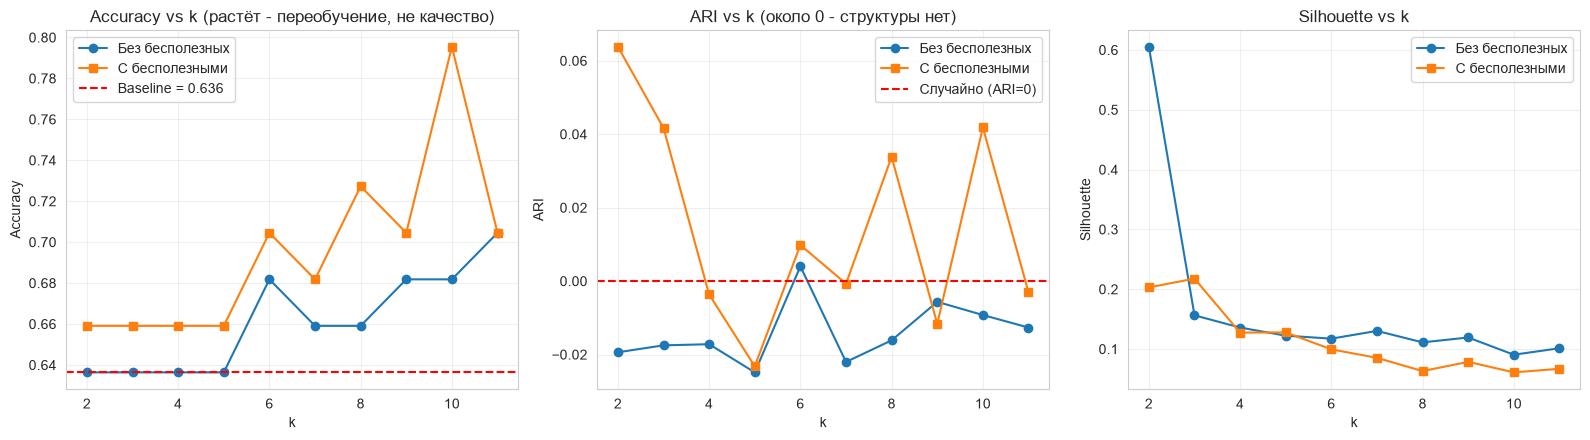

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(res_clean.index, res_clean['accuracy'], 'o-', label='Без бесполезных')
axes[0].plot(res_full.index, res_full['accuracy'], 's-', label='С бесполезными')
axes[0].axhline(baseline, color='red', linestyle='--', label=f'Baseline = {baseline:.3f}')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs k (растёт - переобучение, не качество)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(res_clean.index, res_clean['ARI'], 'o-', label='Без бесполезных')
axes[1].plot(res_full.index, res_full['ARI'], 's-', label='С бесполезными')
axes[1].axhline(0, color='red', linestyle='--', label='Случайно (ARI=0)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('ARI')
axes[1].set_title('ARI vs k (около 0 - структуры нет)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(res_clean.index, res_clean['silhouette'], 'o-', label='Без бесполезных')
axes[2].plot(res_full.index, res_full['silhouette'], 's-', label='С бесполезными')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Silhouette')
axes[2].set_title('Silhouette vs k')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Интерпретация:**

- Accuracy растёт с k - но это артефакт. Чем больше кластеров, тем легче «подогнать» метки под классы большинства.
- ARI при всех k колеблется около 0 - структуры нет.
- Silhouette максимален при k=2.

## 9. Интерактивное предсказание

In [12]:
def predict_phone(answers):
    input_df = pd.DataFrame([answers])
    X_input = prep_clean.transform(input_df)
    cluster = int(km_clean.predict(X_input)[0])
    return 'Айфон' if c2l_clean[cluster] == 1 else 'Андроид'


example = {
    'feeling_attention': 'Комфортно',
    'purchase_decisions': 'Рационально',
    'complex_tech_approach': 'Чтобы всё сразу работало из коробки',
    'everyday_item_choice': 'Какой-то уникальный вариант',
    'phone_discharges_fast': 'Да',
    'often_photo_video': 'Нет',
    'interior_clothing_factor': 'Дизайн, эстетика',
    'phone_lags': 'Нет',
    'apps_work_same': 'Да',
    'love_travel': 'Да',
    'change_phone_years': 4,
    'games_hours_week': 5,
    'publish_photos_videos': 'Нет',
    'watch_movies_phone': 'Да'
}

true_answer = 'Айфон'
predicted = predict_phone(example)

print(f"Предсказание модели: {predicted}")
print(f"Настоящий ответ:     {true_answer}")
print(f"Совпадение: {'Да' if predicted == true_answer else 'Нет'}")

Предсказание модели: Андроид
Настоящий ответ:     Айфон
Совпадение: Нет


**Интерпретация:** модель предсказывает «Андроид», истина - «Айфон». Это подтверждает: модель почти всегда отвечает «Андроид». Технически функция работает, но её ответы не несут информации.

## 10. Итоговые выводы

**Основные результаты.** Сводная таблица двух моделей:

| Модель | Accuracy | F1(Айфон) | ARI | Мин. кластер |
|---|---|---|---|---|
| Без бесполезных (14 признаков) | 0.614 | 0.000 | −0.019 | 1 (вырождение) |
| С бесполезными (67 признаков) | 0.659 | 0.400 | 0.064 | 9 |
| Baseline (всегда «Андроид») | 0.636 | 0.000 | - | - |

Гипотеза о «бесполезных» колонках не подтвердилась. Удаление `timestamp`, `eye_color` и `metro_station` привело к вырождению кластеров - все объекты, кроме одного, попали в один кластер. В высокоразмерном пространстве шум (случайные признаки) работает как регуляризатор: он мешает всем точкам «схлопнуться» в одну группу.

**Принципиальная проблема и ограничение.** K-means не подходит для этой задачи. При k=2 обе модели работают на уровне baseline или чуть выше: accuracy 0.61–0.66 при baseline 0.636 - разница статистически незначима; ARI около 0 при всех k = 2…11 - кластеры не совпадают с классами; F1(Айфон) либо 0, либо 0.4 - модель почти не распознаёт iPhone. Рост accuracy с ростом k - это артефакт majority-voting (чем больше кластеров, тем легче подогнать метку под большинство), а не улучшение качества. Главное ограничение работы объём выборки: всего 44 наблюдения при 14–67 признаках. При таком соотношении объектов и признаков любой метод будет переобучаться и показывать нестабильные результаты. Для получения надёжных выводов нужно как минимум несколько сотен респондентов.